# Part 1d: Weight Initialization Strategies

Proper weight initialization is crucial for training deep neural networks. Poor initialization can lead to vanishing/exploding gradients, slow convergence, or failure to train.

## Topics Covered:
1. The Importance of Weight Initialization
2. Xavier/Glorot Initialization
3. He/Kaiming Initialization
4. LeCun Initialization
5. Orthogonal Initialization
6. Comparison and When to Use Each

**Author:** Advanced Deep Learning Course Assignment

## Why Initialization Matters

### Problems with Poor Initialization:

1. **Vanishing Gradients**: Weights too small → activations shrink → gradients vanish
2. **Exploding Gradients**: Weights too large → activations explode → training unstable
3. **Symmetry Breaking**: All same weights → all neurons learn the same thing

### Goal of Good Initialization:
- Maintain variance of activations across layers
- Maintain variance of gradients during backpropagation
- Break symmetry between neurons

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
# Part A: Weight Initialization in TensorFlow/Keras

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers

print(f"TensorFlow version: {tf.__version__}")
tf.random.set_seed(42)

TensorFlow version: 2.19.0


In [3]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Use subset for faster experiments
X_train = X_train[:10000]
y_train = y_train[:10000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Initialization Methods Overview

| Method | Formula | Best For |
|--------|---------|----------|
| **Xavier/Glorot Uniform** | U(-√(6/(fan_in+fan_out)), √(6/(fan_in+fan_out))) | tanh, sigmoid |
| **Xavier/Glorot Normal** | N(0, √(2/(fan_in+fan_out))) | tanh, sigmoid |
| **He/Kaiming Uniform** | U(-√(6/fan_in), √(6/fan_in)) | ReLU and variants |
| **He/Kaiming Normal** | N(0, √(2/fan_in)) | ReLU and variants |
| **LeCun Normal** | N(0, √(1/fan_in)) | SELU |
| **Orthogonal** | QR decomposition | RNNs, deep networks |

In [4]:
def create_model_with_init(initializer, activation='relu'):
    """
    Create a deep network with specified weight initializer.
    Returns both the full model and a list of layers for activation analysis.
    """
    # Create model using Functional API for easier layer access
    inputs = keras.Input(shape=(784,))
    x = layers.Dense(256, activation=activation, kernel_initializer=initializer)(inputs)
    x = layers.Dense(256, activation=activation, kernel_initializer=initializer)(x)
    x = layers.Dense(256, activation=activation, kernel_initializer=initializer)(x)
    x = layers.Dense(256, activation=activation, kernel_initializer=initializer)(x)
    x = layers.Dense(256, activation=activation, kernel_initializer=initializer)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def analyze_activations(model, X_sample):
    """
    Analyze activation statistics for each layer.
    Uses manual forward pass to get intermediate activations.
    Compatible with Keras 3.x.
    """
    # Get activations by manually passing through each layer
    activations = []
    x = X_sample

    # Iterate through layers (skip last softmax layer)
    for i, layer in enumerate(model.layers[1:-1]):  # Skip Input and last Dense
        x = layer(x)
        activations.append(x.numpy())

    stats = []
    for i, act in enumerate(activations):
        # Check if activation is ReLU-like (has zeros)
        is_relu = np.any(act == 0) and np.all(act >= 0)
        stats.append({
            'layer': i + 1,
            'mean': np.mean(act),
            'std': np.std(act),
            'dead_ratio': np.mean(act == 0) if is_relu else 0
        })

    return stats, activations

### 1. Xavier/Glorot Initialization

Designed for sigmoid and tanh activations. Maintains variance across layers.

In [5]:
# Glorot Uniform (default in Keras)
print("=" * 50)
print("GLOROT/XAVIER UNIFORM INITIALIZATION")
print("=" * 50)

glorot_uniform_model = create_model_with_init(
    initializers.GlorotUniform(seed=42),
    activation='tanh'  # Glorot works best with tanh/sigmoid
)

# Analyze activations before training
X_sample = X_train[:100]
stats, _ = analyze_activations(glorot_uniform_model, X_sample)

print("\nActivation statistics (before training):")
for s in stats:
    print(f"Layer {s['layer']}: Mean = {s['mean']:.4f}, Std = {s['std']:.4f}")

GLOROT/XAVIER UNIFORM INITIALIZATION

Activation statistics (before training):
Layer 1: Mean = 0.0083, Std = 0.3533
Layer 2: Mean = 0.0056, Std = 0.3255
Layer 3: Mean = -0.0091, Std = 0.3050
Layer 4: Mean = -0.0017, Std = 0.2747
Layer 5: Mean = -0.0006, Std = 0.2601


In [6]:
# Glorot Normal
print("\n" + "=" * 50)
print("GLOROT/XAVIER NORMAL INITIALIZATION")
print("=" * 50)

glorot_normal_model = create_model_with_init(
    initializers.GlorotNormal(seed=42),
    activation='tanh'
)

stats, _ = analyze_activations(glorot_normal_model, X_sample)

print("\nActivation statistics (before training):")
for s in stats:
    print(f"Layer {s['layer']}: Mean = {s['mean']:.4f}, Std = {s['std']:.4f}")


GLOROT/XAVIER NORMAL INITIALIZATION

Activation statistics (before training):
Layer 1: Mean = 0.0021, Std = 0.3423
Layer 2: Mean = 0.0187, Std = 0.3054
Layer 3: Mean = -0.0164, Std = 0.2745
Layer 4: Mean = 0.0043, Std = 0.2606
Layer 5: Mean = 0.0060, Std = 0.2504


### 2. He/Kaiming Initialization

Designed for ReLU and its variants. Accounts for the fact that ReLU zeros out negative values.

In [7]:
print("=" * 50)
print("HE/KAIMING UNIFORM INITIALIZATION")
print("=" * 50)

he_uniform_model = create_model_with_init(
    initializers.HeUniform(seed=42),
    activation='relu'  # He works best with ReLU
)

stats, _ = analyze_activations(he_uniform_model, X_sample)

print("\nActivation statistics (before training):")
for s in stats:
    print(f"Layer {s['layer']}: Mean = {s['mean']:.4f}, Std = {s['std']:.4f}, Dead neurons = {s['dead_ratio']*100:.1f}%")

HE/KAIMING UNIFORM INITIALIZATION

Activation statistics (before training):
Layer 1: Mean = 0.1897, Std = 0.2809, Dead neurons = 49.0%
Layer 2: Mean = 0.1945, Std = 0.2951, Dead neurons = 50.2%
Layer 3: Mean = 0.2043, Std = 0.3109, Dead neurons = 50.0%
Layer 4: Mean = 0.2042, Std = 0.3102, Dead neurons = 49.2%
Layer 5: Mean = 0.2189, Std = 0.3157, Dead neurons = 46.4%


In [8]:
print("\n" + "=" * 50)
print("HE/KAIMING NORMAL INITIALIZATION")
print("=" * 50)

he_normal_model = create_model_with_init(
    initializers.HeNormal(seed=42),
    activation='relu'
)

stats, _ = analyze_activations(he_normal_model, X_sample)

print("\nActivation statistics (before training):")
for s in stats:
    print(f"Layer {s['layer']}: Mean = {s['mean']:.4f}, Std = {s['std']:.4f}, Dead neurons = {s['dead_ratio']*100:.1f}%")


HE/KAIMING NORMAL INITIALIZATION

Activation statistics (before training):
Layer 1: Mean = 0.1772, Std = 0.2604, Dead neurons = 49.1%
Layer 2: Mean = 0.1879, Std = 0.2653, Dead neurons = 47.0%
Layer 3: Mean = 0.1737, Std = 0.2592, Dead neurons = 49.7%
Layer 4: Mean = 0.1779, Std = 0.2600, Dead neurons = 48.0%
Layer 5: Mean = 0.1798, Std = 0.2639, Dead neurons = 49.4%


### 3. LeCun Initialization

Designed for SELU activation (Self-Normalizing Neural Networks).

In [9]:
print("=" * 50)
print("LECUN NORMAL INITIALIZATION")
print("=" * 50)

lecun_model = create_model_with_init(
    initializers.LecunNormal(seed=42),
    activation='selu'  # LeCun works with SELU
)

stats, _ = analyze_activations(lecun_model, X_sample)

print("\nActivation statistics (before training):")
for s in stats:
    print(f"Layer {s['layer']}: Mean = {s['mean']:.4f}, Std = {s['std']:.4f}")

LECUN NORMAL INITIALIZATION

Activation statistics (before training):
Layer 1: Mean = -0.0488, Std = 0.3879
Layer 2: Mean = -0.0299, Std = 0.4568
Layer 3: Mean = -0.0878, Std = 0.5235
Layer 4: Mean = -0.0413, Std = 0.6054
Layer 5: Mean = -0.0344, Std = 0.6830


### 4. Orthogonal Initialization

Preserves gradient norms during backpropagation. Good for RNNs and very deep networks.

In [10]:
print("=" * 50)
print("ORTHOGONAL INITIALIZATION")
print("=" * 50)

orthogonal_model = create_model_with_init(
    initializers.Orthogonal(seed=42),
    activation='relu'
)

stats, _ = analyze_activations(orthogonal_model, X_sample)

print("\nActivation statistics (before training):")
for s in stats:
    print(f"Layer {s['layer']}: Mean = {s['mean']:.4f}, Std = {s['std']:.4f}")

ORTHOGONAL INITIALIZATION

Activation statistics (before training):
Layer 1: Mean = 0.1309, Std = 0.1967
Layer 2: Mean = 0.0926, Std = 0.1398
Layer 3: Mean = 0.0671, Std = 0.0972
Layer 4: Mean = 0.0468, Std = 0.0700
Layer 5: Mean = 0.0338, Std = 0.0508


## Comparison: Wrong vs Right Initialization

In [11]:
# Compare: Glorot with ReLU (wrong) vs He with ReLU (right)
print("Comparing WRONG vs RIGHT initialization for ReLU:")
print("\n1. Glorot with ReLU (WRONG):")

wrong_model = create_model_with_init(
    initializers.GlorotUniform(seed=42),
    activation='relu'  # Wrong! Glorot is for tanh/sigmoid
)

stats_wrong, acts_wrong = analyze_activations(wrong_model, X_sample)
for s in stats_wrong:
    print(f"Layer {s['layer']}: Std = {s['std']:.4f}")

print("\n2. He with ReLU (RIGHT):")
stats_right, acts_right = analyze_activations(he_uniform_model, X_sample)
for s in stats_right:
    print(f"Layer {s['layer']}: Std = {s['std']:.4f}")

Comparing WRONG vs RIGHT initialization for ReLU:

1. Glorot with ReLU (WRONG):
Layer 1: Std = 0.2439
Layer 2: Std = 0.1812
Layer 3: Std = 0.1350
Layer 4: Std = 0.0952
Layer 5: Std = 0.0685

2. He with ReLU (RIGHT):
Layer 1: Std = 0.2809
Layer 2: Std = 0.2951
Layer 3: Std = 0.3109
Layer 4: Std = 0.3102
Layer 5: Std = 0.3157


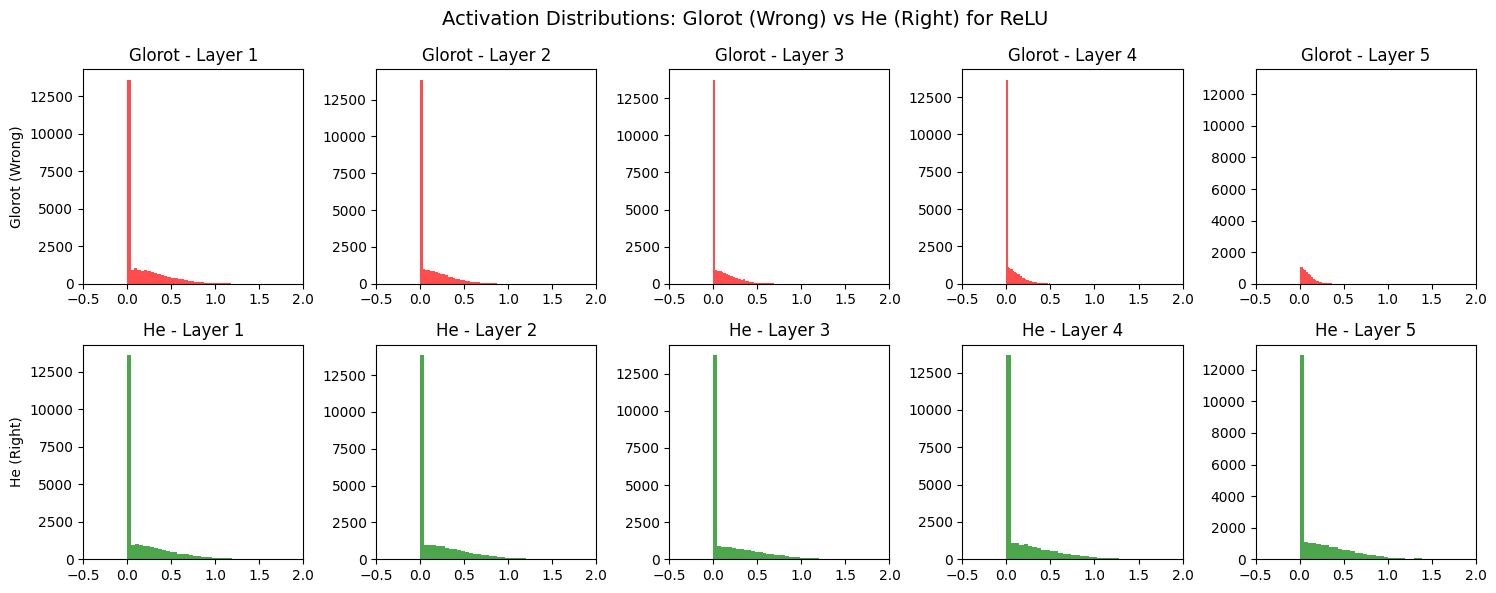

Notice: With Glorot, variance shrinks through layers. With He, it stays stable.


In [12]:
# Visualize activation distributions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Activation Distributions: Glorot (Wrong) vs He (Right) for ReLU', fontsize=14)

for i in range(5):
    # Glorot (wrong)
    axes[0, i].hist(acts_wrong[i].flatten(), bins=50, alpha=0.7, color='red')
    axes[0, i].set_title(f'Glorot - Layer {i+1}')
    axes[0, i].set_xlim(-0.5, 2)

    # He (right)
    axes[1, i].hist(acts_right[i].flatten(), bins=50, alpha=0.7, color='green')
    axes[1, i].set_title(f'He - Layer {i+1}')
    axes[1, i].set_xlim(-0.5, 2)

axes[0, 0].set_ylabel('Glorot (Wrong)')
axes[1, 0].set_ylabel('He (Right)')

plt.tight_layout()
plt.show()

print("Notice: With Glorot, variance shrinks through layers. With He, it stays stable.")

## Training Comparison

In [13]:
# Train models with different initializations and compare
initializations = [
    ('Glorot Uniform (tanh)', initializers.GlorotUniform(seed=42), 'tanh'),
    ('He Normal (ReLU)', initializers.HeNormal(seed=42), 'relu'),
    ('LeCun Normal (SELU)', initializers.LecunNormal(seed=42), 'selu'),
    ('Orthogonal (ReLU)', initializers.Orthogonal(seed=42), 'relu'),
]

histories = []
labels = []

for name, init, activation in initializations:
    print(f"\nTraining: {name}")
    model = create_model_with_init(init, activation)

    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    histories.append(history)
    labels.append(name)

    # Evaluate
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Accuracy: {test_acc:.4f}")


Training: Glorot Uniform (tanh)
Test Accuracy: 0.9380

Training: He Normal (ReLU)
Test Accuracy: 0.9421

Training: LeCun Normal (SELU)
Test Accuracy: 0.9286

Training: Orthogonal (ReLU)
Test Accuracy: 0.9600


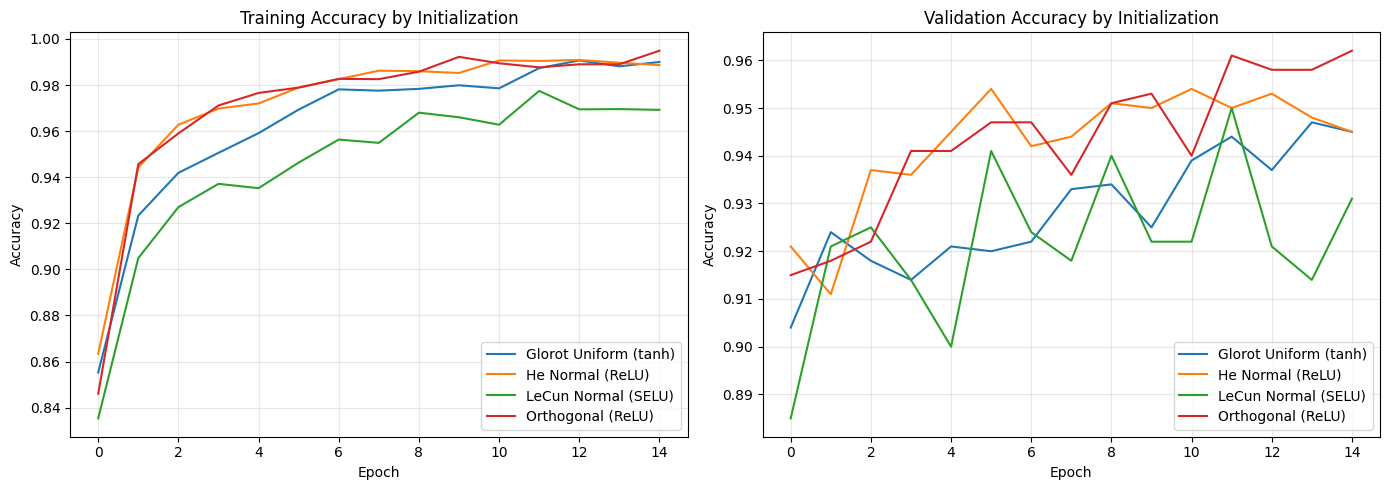

In [14]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for history, label in zip(histories, labels):
    axes[0].plot(history.history['accuracy'], label=label)
axes[0].set_title('Training Accuracy by Initialization')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for history, label in zip(histories, labels):
    axes[1].plot(history.history['val_accuracy'], label=label)
axes[1].set_title('Validation Accuracy by Initialization')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part B: Weight Initialization in PyTorch

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)

PyTorch version: 2.10.0+cu128
Using device: cuda


In [16]:
# Load MNIST for PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dataset = torch.utils.data.Subset(train_dataset, range(10000))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 429kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.79MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.37MB/s]


In [17]:
class DeepNet(nn.Module):
    """
    Deep neural network with customizable initialization.
    """
    def __init__(self, activation='relu'):
        super(DeepNet, self).__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 256)
        self.fc4 = nn.Linear(256, 256)
        self.fc5 = nn.Linear(256, 256)
        self.fc6 = nn.Linear(256, 10)

        self.activation = activation

        # Store activation functions
        if activation == 'relu':
            self.act_fn = F.relu
        elif activation == 'tanh':
            self.act_fn = torch.tanh
        elif activation == 'selu':
            self.act_fn = F.selu
        elif activation == 'leaky_relu':
            self.act_fn = F.leaky_relu

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.act_fn(self.fc1(x))
        x = self.act_fn(self.fc2(x))
        x = self.act_fn(self.fc3(x))
        x = self.act_fn(self.fc4(x))
        x = self.act_fn(self.fc5(x))
        x = self.fc6(x)
        return x

    def apply_init(self, init_fn):
        """Apply initialization function to all linear layers."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                init_fn(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

In [18]:
# PyTorch Initialization Functions
def xavier_uniform_init(weight):
    nn.init.xavier_uniform_(weight)

def xavier_normal_init(weight):
    nn.init.xavier_normal_(weight)

def kaiming_uniform_init(weight):
    nn.init.kaiming_uniform_(weight, mode='fan_in', nonlinearity='relu')

def kaiming_normal_init(weight):
    nn.init.kaiming_normal_(weight, mode='fan_in', nonlinearity='relu')

def orthogonal_init(weight):
    nn.init.orthogonal_(weight)

def lecun_normal_init(weight):
    # LeCun normal: std = sqrt(1/fan_in)
    fan_in = weight.size(1)
    std = np.sqrt(1.0 / fan_in)
    nn.init.normal_(weight, mean=0, std=std)

In [19]:
def analyze_pytorch_activations(model, X_sample):
    """
    Analyze activation statistics for PyTorch model.
    """
    model.eval()
    activations = []

    x = X_sample.view(-1, 784)

    with torch.no_grad():
        for i, layer in enumerate([model.fc1, model.fc2, model.fc3, model.fc4, model.fc5]):
            x = layer(x)
            x = model.act_fn(x)
            activations.append(x.cpu().numpy())

    stats = []
    for i, act in enumerate(activations):
        stats.append({
            'layer': i + 1,
            'mean': np.mean(act),
            'std': np.std(act)
        })

    return stats, activations

# Get sample data
sample_data, _ = next(iter(train_loader))
sample_data = sample_data.to(device)

In [20]:
# Compare initializations in PyTorch
print("=" * 60)
print("PYTORCH INITIALIZATION COMPARISON")
print("=" * 60)

init_configs = [
    ('Xavier Uniform', xavier_uniform_init, 'tanh'),
    ('Kaiming Normal', kaiming_normal_init, 'relu'),
    ('Orthogonal', orthogonal_init, 'relu'),
    ('LeCun Normal', lecun_normal_init, 'selu'),
]

for name, init_fn, activation in init_configs:
    print(f"\n{name} with {activation.upper()}:")
    model = DeepNet(activation=activation).to(device)
    model.apply_init(init_fn)

    stats, _ = analyze_pytorch_activations(model, sample_data)
    for s in stats:
        print(f"  Layer {s['layer']}: Mean = {s['mean']:.4f}, Std = {s['std']:.4f}")

PYTORCH INITIALIZATION COMPARISON

Xavier Uniform with TANH:
  Layer 1: Mean = 0.0141, Std = 0.6822
  Layer 2: Mean = 0.0000, Std = 0.5159
  Layer 3: Mean = 0.0124, Std = 0.4225
  Layer 4: Mean = -0.0089, Std = 0.3698
  Layer 5: Mean = 0.0020, Std = 0.3309

Kaiming Normal with RELU:
  Layer 1: Mean = 0.5702, Std = 0.8370
  Layer 2: Mean = 0.5557, Std = 0.8173
  Layer 3: Mean = 0.5362, Std = 0.8274
  Layer 4: Mean = 0.5917, Std = 0.8069
  Layer 5: Mean = 0.5752, Std = 0.8523

Orthogonal with RELU:
  Layer 1: Mean = 0.3848, Std = 0.6021
  Layer 2: Mean = 0.2666, Std = 0.4119
  Layer 3: Mean = 0.1798, Std = 0.2768
  Layer 4: Mean = 0.1277, Std = 0.1942
  Layer 5: Mean = 0.1083, Std = 0.1439

LeCun Normal with SELU:
  Layer 1: Mean = 0.0532, Std = 1.0367
  Layer 2: Mean = 0.0172, Std = 1.0244
  Layer 3: Mean = -0.0232, Std = 1.0246
  Layer 4: Mean = -0.0046, Std = 1.0093
  Layer 5: Mean = -0.0472, Std = 0.9803


In [21]:
# Training comparison in PyTorch
def train_pytorch_model(model, train_loader, test_loader, epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)

        train_acc = correct / total
        train_accs.append(train_acc)

        # Test accuracy
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)

        test_acc = correct / total
        test_accs.append(test_acc)

    return train_accs, test_accs

# Train with different initializations
pytorch_results = []

for name, init_fn, activation in init_configs:
    print(f"\nTraining: {name} with {activation}")
    torch.manual_seed(42)
    model = DeepNet(activation=activation).to(device)
    model.apply_init(init_fn)

    train_accs, test_accs = train_pytorch_model(model, train_loader, test_loader, epochs=15)
    pytorch_results.append((name, train_accs, test_accs))
    print(f"Final Test Accuracy: {test_accs[-1]:.4f}")


Training: Xavier Uniform with tanh
Final Test Accuracy: 0.9434

Training: Kaiming Normal with relu
Final Test Accuracy: 0.9368

Training: Orthogonal with relu
Final Test Accuracy: 0.9529

Training: LeCun Normal with selu
Final Test Accuracy: 0.9364


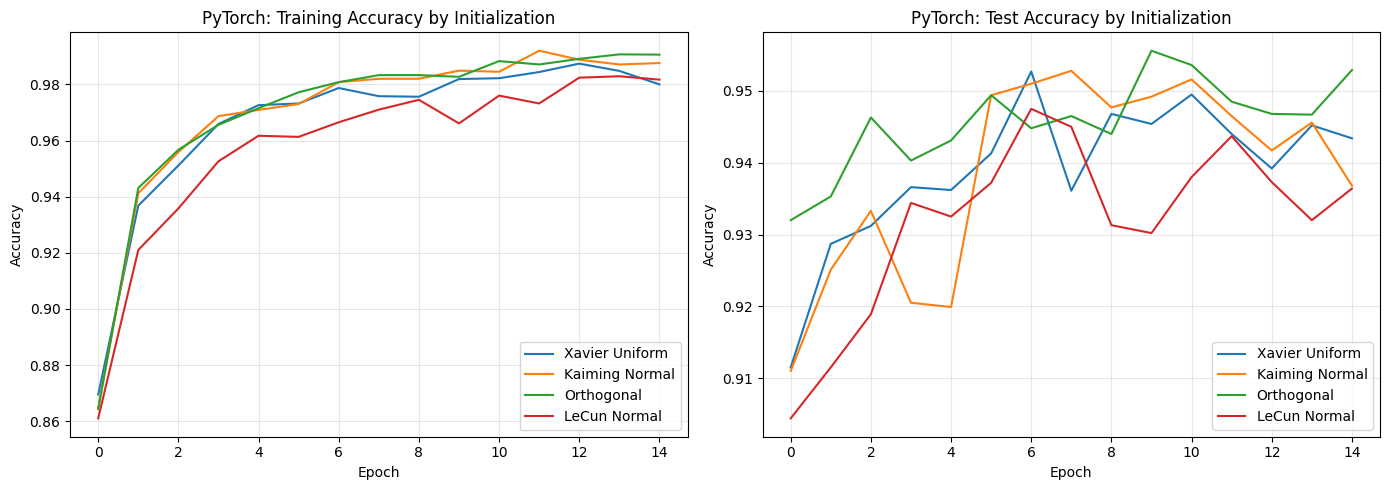

In [22]:
# Plot PyTorch results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, train_accs, test_accs in pytorch_results:
    axes[0].plot(train_accs, label=name)
axes[0].set_title('PyTorch: Training Accuracy by Initialization')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, train_accs, test_accs in pytorch_results:
    axes[1].plot(test_accs, label=name)
axes[1].set_title('PyTorch: Test Accuracy by Initialization')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

### Initialization Selection Guide:

| Activation | Recommended Initialization | Why |
|------------|---------------------------|-----|
| **ReLU, Leaky ReLU** | He (Kaiming) | Accounts for ReLU zeroing negative values |
| **tanh, sigmoid** | Xavier (Glorot) | Designed for symmetric activations |
| **SELU** | LeCun | Maintains self-normalizing property |
| **RNN/LSTM** | Orthogonal | Preserves gradient norms through time |

### Key Formulas:

| Method | Variance |
|--------|----------|
| **Xavier** | 2 / (fan_in + fan_out) |
| **He** | 2 / fan_in |
| **LeCun** | 1 / fan_in |

### Best Practices:
1. Match initialization to activation function
2. Use framework defaults when appropriate (Keras uses Glorot by default)
3. For very deep networks (50+ layers), consider orthogonal or specialized init
4. Always check activation statistics to verify proper initialization